In [1]:
import numpy as np
import pandas as pd
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load the persistent 10,000-record dataset
data_path = '/content/drive/MyDrive/cleaned_chronic_data_expanded.csv'
df = pd.read_csv(data_path)

print(f'Dataset successfully loaded! Shape: {df.shape}')
df.tail(3)

Mounted at /content/drive
Dataset successfully loaded! Shape: (10000, 13)


,Age,Gender,Visits (all clinics),Months Since Visit,Care_Duration_Days,Care_Duration_Days_Adjusted,Care_Duration_Months,Visit_Frequency_Density,Age_Group,Disease_Count,Comorbidity_Status,Dynamic_Status,Disease_Clean
9997,55,Male,2,19.1,0,1,0.038945,1.261990,Middle-Aged (36-60),1,Single Condition,Overdue,Asthma
9998,41,Male,4,6.5,342,342,11.235217,0.326925,Middle-Aged (36-60),1,Single Condition,Overdue,Hypertension
9999,59,Male,6,0.6,466,524,17.220228,1.301212,Middle-Aged (36-60),1,Single Condition,On-Schedule,Hypertension


In [2]:
# 1. Calculate Expected Visit Interval (Months per visit)
# Handle zero/near-zero duration by using Care_Duration_Months
df['Expected_Visit_Interval'] = df['Care_Duration_Months'] / np.maximum(
    df['Visits (all clinics)'], 1
)

# 2. Define Binary Target Variable: Target_Overdue
# Patient is overdue (1) if Months Since Visit > 1.5 * Expected Visit Interval, or Months Since Visit > 6 months for single visits
df['Target_Overdue'] = np.where(
    (df['Months Since Visit'] > 1.5 * df['Expected_Visit_Interval'])
    | (
        (df['Visits (all clinics)'] == 1) & (df['Months Since Visit'] > 6)
    ),  # Single-visit cutoff
    1,
    0,
)

# 3. Inspect Target Class Balance
print('=== TARGET VARIABLE DISTRIBUTION ===')
print(df['Target_Overdue'].value_counts(normalize=True).round(4) * 100)
print('\nRaw Counts:')
print(df['Target_Overdue'].value_counts())

=== TARGET VARIABLE DISTRIBUTION ===
Target_Overdue
1    65.49
0    34.51
Name: proportion, dtype: float64

Raw Counts:
Target_Overdue
1    6549
0    3451
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Drop target leakage and redundant identifier columns
leakage_cols = [
    'Target_Overdue',
    'Months Since Visit',
    'Expected_Visit_Interval',
]
X_raw = df.drop(columns=[c for c in leakage_cols if c in df.columns])
y = df['Target_Overdue']

# 2. Categorical Encoding (One-Hot Encoding)
categorical_cols = [
    'Gender',
    'Age_Group',
    'Disease_Clean',
    'Comorbidity_Status',
    'Dynamic_Status',
]
existing_cat_cols = [c for c in categorical_cols if c in X_raw.columns]

X_encoded = pd.get_dummies(X_raw, columns=existing_cat_cols, drop_first=True)

# 3. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Scale Numerical Features
scaler = StandardScaler()
numerical_cols = [
    'Age',
    'Visits (all clinics)',
    'Care_Duration_Days',
    'Care_Duration_Days_Adjusted',
    'Care_Duration_Months',
    'Visit_Frequency_Density',
    'Disease_Count',
]
existing_num_cols = [c for c in numerical_cols if c in X_train.columns]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[existing_num_cols] = scaler.fit_transform(
    X_train[existing_num_cols]
)
X_test_scaled[existing_num_cols] = scaler.transform(X_test[existing_num_cols])

print('=== DATA PREPROCESSING COMPLETE ===')
print(f'Training Feature Matrix (X_train): {X_train_scaled.shape}')
print(f'Testing Feature Matrix (X_test):   {X_test_scaled.shape}')
print(f'Train Target Class Ratio: {y_train.mean():.4f}')
print(f'Test Target Class Ratio:  {y_test.mean():.4f}')

=== DATA PREPROCESSING COMPLETE ===
Training Feature Matrix (X_train): (8000, 26)
Testing Feature Matrix (X_test):   (2000, 26)
Train Target Class Ratio: 0.6549
Test Target Class Ratio:  0.6550


=== LOGISTIC REGRESSION: CROSS-VALIDATION RESULTS (5-FOLD) ===
Mean CV ROC-AUC: 0.8791 (+/- 0.0093)
Mean CV F1-Score: 0.8511 (+/- 0.0120)

=== HELD-OUT TEST SET PERFORMANCE ===
Test Accuracy:  0.8120
Test ROC-AUC:   0.8919
Test F1-Score:  0.8585

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72       690
           1       0.85      0.87      0.86      1310

    accuracy                           0.81      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.81      0.81      0.81      2000



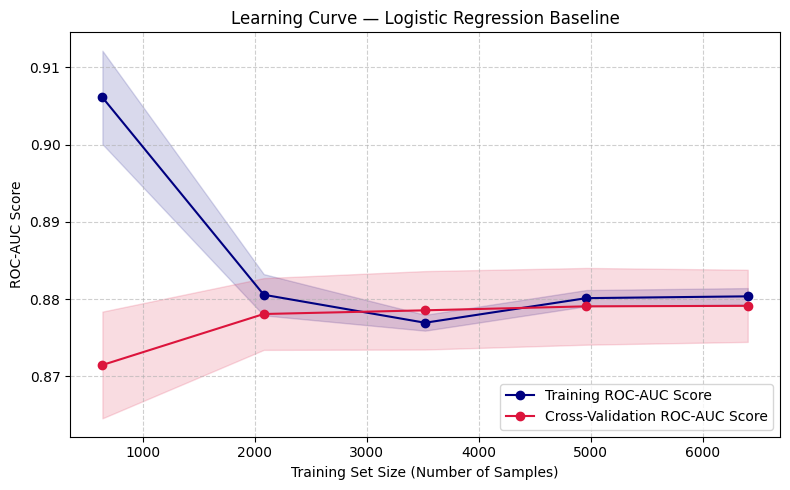

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import KFold, cross_val_score, learning_curve

# 1. Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Perform 5-Fold Stratified Cross-Validation on Training Data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_auc = cross_val_score(
    log_reg, X_train_scaled, y_train, cv=kf, scoring='roc_auc'
)
cv_scores_f1 = cross_val_score(
    log_reg, X_train_scaled, y_train, cv=kf, scoring='f1'
)

print('=== LOGISTIC REGRESSION: CROSS-VALIDATION RESULTS (5-FOLD) ===')
print(
    f'Mean CV ROC-AUC: {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std() * 2:.4f})'
)
print(
    f'Mean CV F1-Score: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std() * 2:.4f})\n'
)

# 3. Fit on Full Training Set and Evaluate on Held-Out Test Set
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print('=== HELD-OUT TEST SET PERFORMANCE ===')
print(f'Test Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Test ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'Test F1-Score:  {f1_score(y_test, y_pred_lr):.4f}\n')

print('Classification Report:')
print(classification_report(y_test, y_pred_lr))

# 4. Generate & Plot Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    log_reg,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=42,
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color='navy',
    label='Training ROC-AUC Score',
)
plt.plot(
    train_sizes,
    val_mean,
    'o-',
    color='crimson',
    label='Cross-Validation ROC-AUC Score',
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color='navy',
)
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color='crimson',
)

plt.title('Learning Curve — Logistic Regression Baseline')
plt.xlabel('Training Set Size (Number of Samples)')
plt.ylabel('ROC-AUC Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

=== RANDOM FOREST: CROSS-VALIDATION RESULTS (5-FOLD) ===
Mean CV ROC-AUC: 0.8904 (+/- 0.0042)
Mean CV F1-Score: 0.8502 (+/- 0.0069)

=== HELD-OUT TEST SET PERFORMANCE ===
Test Accuracy:  0.8235
Test ROC-AUC:   0.9010
Test F1-Score:  0.8610

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.80      0.76       690
           1       0.89      0.83      0.86      1310

    accuracy                           0.82      2000
   macro avg       0.80      0.82      0.81      2000
weighted avg       0.83      0.82      0.83      2000



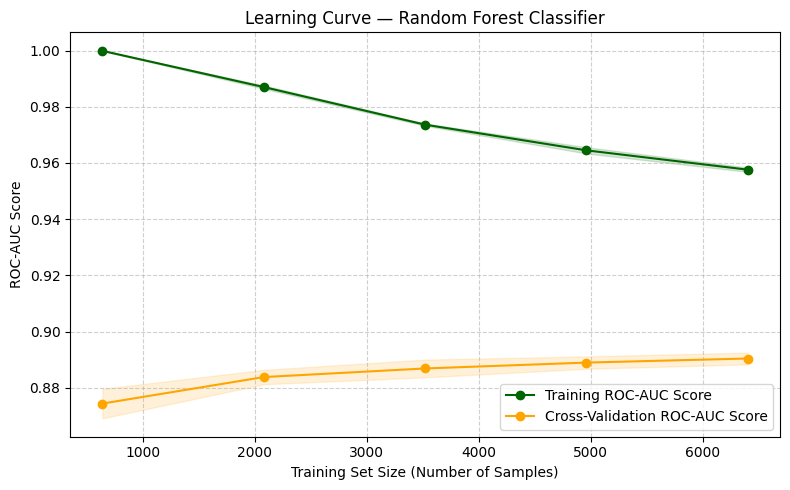

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import KFold, cross_val_score, learning_curve

# 1. Initialize Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

# 2. Perform 5-Fold Stratified Cross-Validation on Unscaled Training Data
# (Tree-based models do not require scaled numerical features)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_auc = cross_val_score(
    rf_model, X_train, y_train, cv=kf, scoring='roc_auc'
)
cv_scores_f1 = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='f1')

print('=== RANDOM FOREST: CROSS-VALIDATION RESULTS (5-FOLD) ===')
print(
    f'Mean CV ROC-AUC: {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std() * 2:.4f})'
)
print(
    f'Mean CV F1-Score: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std() * 2:.4f})\n'
)

# 3. Fit on Full Training Set and Evaluate on Held-Out Test Set
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print('=== HELD-OUT TEST SET PERFORMANCE ===')
print(f'Test Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Test ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'Test F1-Score:  {f1_score(y_test, y_pred_rf):.4f}\n')

print('Classification Report:')
print(classification_report(y_test, y_pred_rf))

# 4. Generate & Plot Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train,
    y_train,
    cv=kf,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=42,
    n_jobs=-1,
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color='darkgreen',
    label='Training ROC-AUC Score',
)
plt.plot(
    train_sizes,
    val_mean,
    'o-',
    color='orange',
    label='Cross-Validation ROC-AUC Score',
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color='darkgreen',
)
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color='orange',
)

plt.title('Learning Curve — Random Forest Classifier')
plt.xlabel('Training Set Size (Number of Samples)')
plt.ylabel('ROC-AUC Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

=== XGBOOST: CROSS-VALIDATION RESULTS (5-FOLD) ===
Mean CV ROC-AUC: 0.8929 (+/- 0.0053)
Mean CV F1-Score: 0.8493 (+/- 0.0084)

=== HELD-OUT TEST SET PERFORMANCE ===
Test Accuracy:  0.8265
Test ROC-AUC:   0.9026
Test F1-Score:  0.8641

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76       690
           1       0.89      0.84      0.86      1310

    accuracy                           0.83      2000
   macro avg       0.81      0.82      0.81      2000
weighted avg       0.83      0.83      0.83      2000



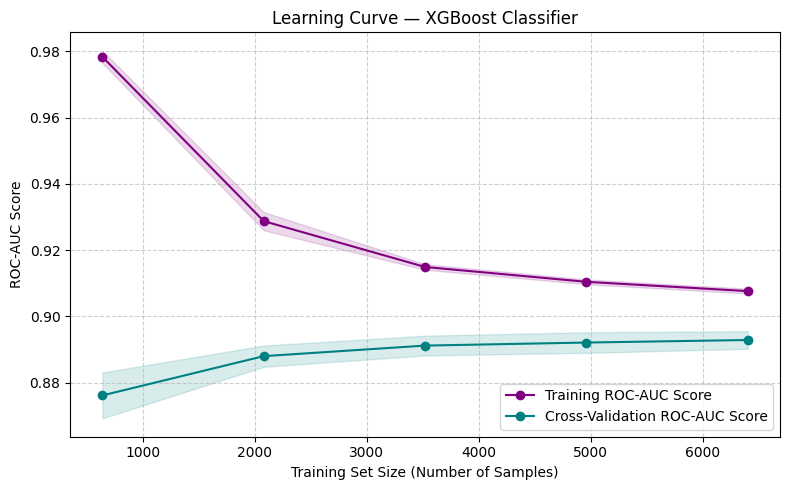

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from xgboost import XGBClassifier

# 1. Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,  # Shallower depth to combat overfitting seen in RF
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

# 2. Perform 5-Fold Stratified Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_auc = cross_val_score(
    xgb_model, X_train, y_train, cv=kf, scoring='roc_auc'
)
cv_scores_f1 = cross_val_score(
    xgb_model, X_train, y_train, cv=kf, scoring='f1'
)

print('=== XGBOOST: CROSS-VALIDATION RESULTS (5-FOLD) ===')
print(
    f'Mean CV ROC-AUC: {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std() * 2:.4f})'
)
print(
    f'Mean CV F1-Score: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std() * 2:.4f})\n'
)

# 3. Fit on Full Training Set and Evaluate on Held-Out Test Set
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('=== HELD-OUT TEST SET PERFORMANCE ===')
print(f'Test Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'Test ROC-AUC:   {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'Test F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}\n')

print('Classification Report:')
print(classification_report(y_test, y_pred_xgb))

# 4. Generate & Plot Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    xgb_model,
    X_train,
    y_train,
    cv=kf,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=42,
    n_jobs=-1,
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color='purple',
    label='Training ROC-AUC Score',
)
plt.plot(
    train_sizes,
    val_mean,
    'o-',
    color='teal',
    label='Cross-Validation ROC-AUC Score',
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color='purple',
)
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color='teal',
)

plt.title('Learning Curve — XGBoost Classifier')
plt.xlabel('Training Set Size (Number of Samples)')
plt.ylabel('ROC-AUC Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

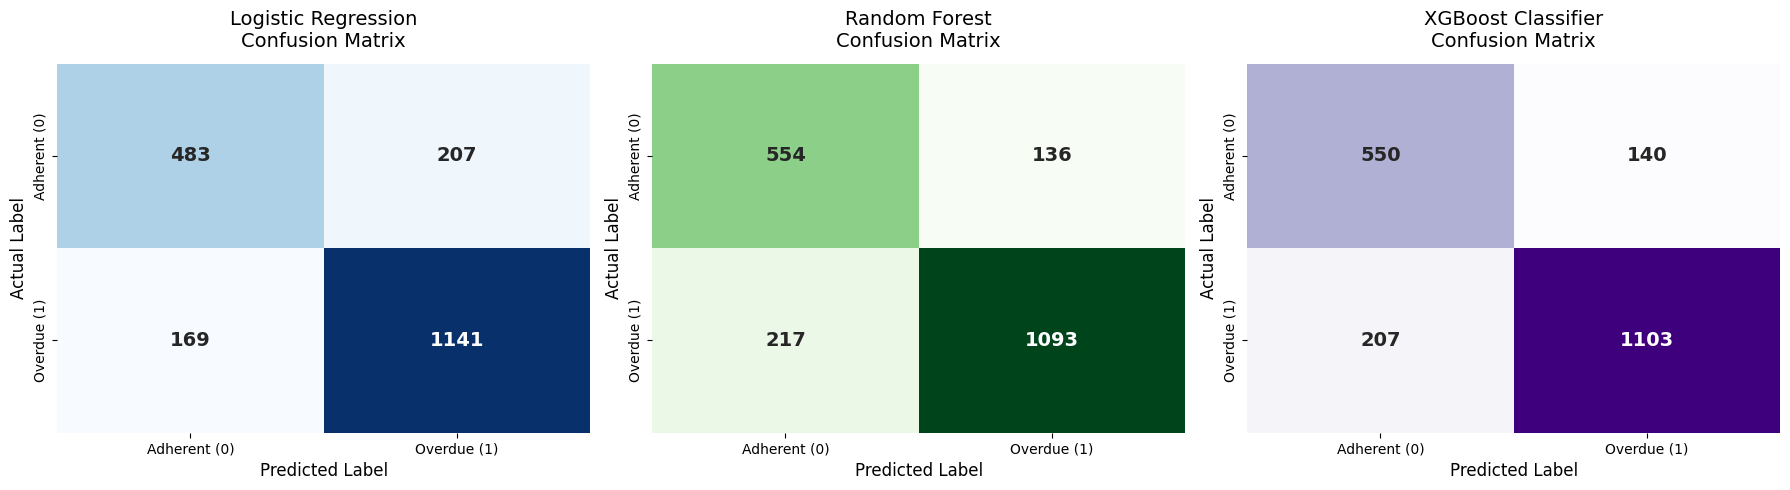

=== OPERATIONAL RISK BREAKDOWN (TEST SET: 2,000 PATIENTS) ===

--- Logistic Regression ---
 True Positives (Correct Overdue Catch): 1,141 patients
 True Negatives (Correct Adherent Flag): 483 patients
 False Positives (Wasted Follow-up Calls): 207 patients (False Alarms)
 False Negatives (Missed At-Risk Patients): 169 patients (CRITICAL)

--- Random Forest ---
 True Positives (Correct Overdue Catch): 1,093 patients
 True Negatives (Correct Adherent Flag): 554 patients
 False Positives (Wasted Follow-up Calls): 136 patients (False Alarms)
 False Negatives (Missed At-Risk Patients): 217 patients (CRITICAL)

--- XGBoost Classifier ---
 True Positives (Correct Overdue Catch): 1,103 patients
 True Negatives (Correct Adherent Flag): 550 patients
 False Positives (Wasted Follow-up Calls): 140 patients (False Alarms)
 False Negatives (Missed At-Risk Patients): 207 patients (CRITICAL)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute Confusion Matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

models_cm = [
    ('Logistic Regression', cm_lr, 'Blues'),
    ('Random Forest', cm_rf, 'Greens'),
    ('XGBoost Classifier', cm_xgb, 'Purples'),
]

# 2. Plot Side-by-Side Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, cm, cmap) in enumerate(models_cm):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        cbar=False,
        ax=axes[i],
        annot_kws={'size': 14, 'weight': 'bold'},
        xticklabels=['Adherent (0)', 'Overdue (1)'],
        yticklabels=['Adherent (0)', 'Overdue (1)'],
    )

    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=14, pad=12)
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('Actual Label', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Print Operational Breakdown for Decision Making
print('=== OPERATIONAL RISK BREAKDOWN (TEST SET: 2,000 PATIENTS) ===')
for name, cm, _ in models_cm:
    tn, fp, fn, tp = cm.ravel()
    print(f'\n--- {name} ---')
    print(f' True Positives (Correct Overdue Catch): {tp:,} patients')
    print(f' True Negatives (Correct Adherent Flag): {tn:,} patients')
    print(
        f' False Positives (Wasted Follow-up Calls): {fp:,} patients (False Alarms)'
    )
    print(
        f' False Negatives (Missed At-Risk Patients): {fn:,} patients (CRITICAL)'
    )

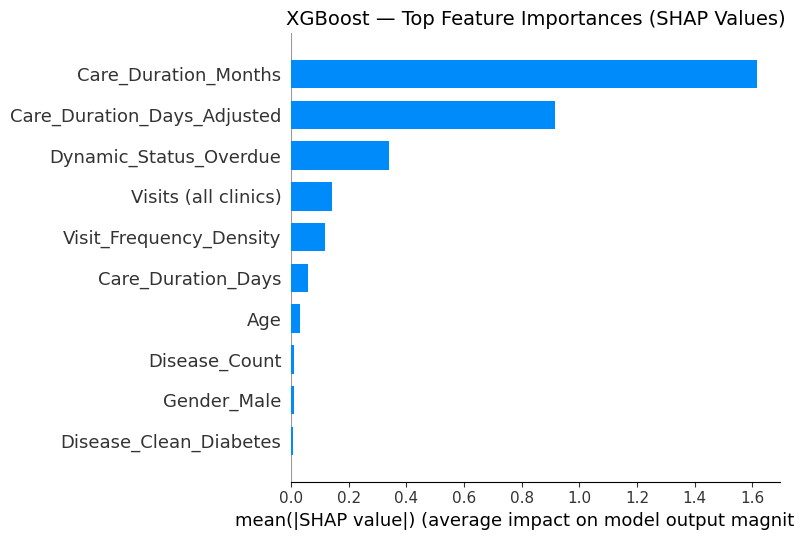

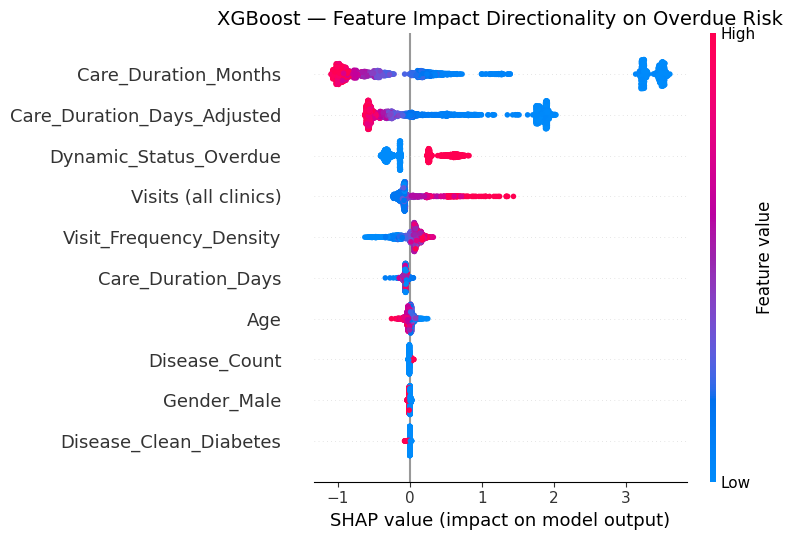

In [8]:
!pip install shap -q

import matplotlib.pyplot as plt
import shap

# 1. Initialize TreeExplainer on trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

# 2. Generate SHAP Summary Plot (Bar chart for absolute impact)
plt.figure(figsize=(10, 6))
plt.title('XGBoost — Top Feature Importances (SHAP Values)', fontsize=14)
shap.summary_plot(
    shap_values, X_test, plot_type='bar', show=False, max_display=10
)
plt.tight_layout()
plt.show()

# 3. Generate SHAP Beeswarm Plot (Shows directionality/impact on target)
plt.figure(figsize=(10, 6))
plt.title(
    'XGBoost — Feature Impact Directionality on Overdue Risk', fontsize=14
)
shap.summary_plot(shap_values, X_test, show=False, max_display=10)
plt.tight_layout()
plt.show()

=== THRESHOLD OPTIMIZATION MATRIX (TEST SET: 2,000 PATIENTS) ===
 Threshold  Missed Overdue (FN)  Caught Overdue (TP)  False Alarms (FP) Recall (Catch Rate)
      0.10                    0                 1310                690              100.0%
      0.15                    3                 1307                668               99.8%
      0.20                   24                 1286                573               98.2%
      0.25                   45                 1265                447               96.6%
      0.30                   81                 1229                364               93.8%
      0.35                  111                 1199                307               91.5%
      0.40                  142                 1168                237               89.2%
      0.45                  179                 1131                189               86.3%
      0.50                  207                 1103                140               84.2%
      0.55     

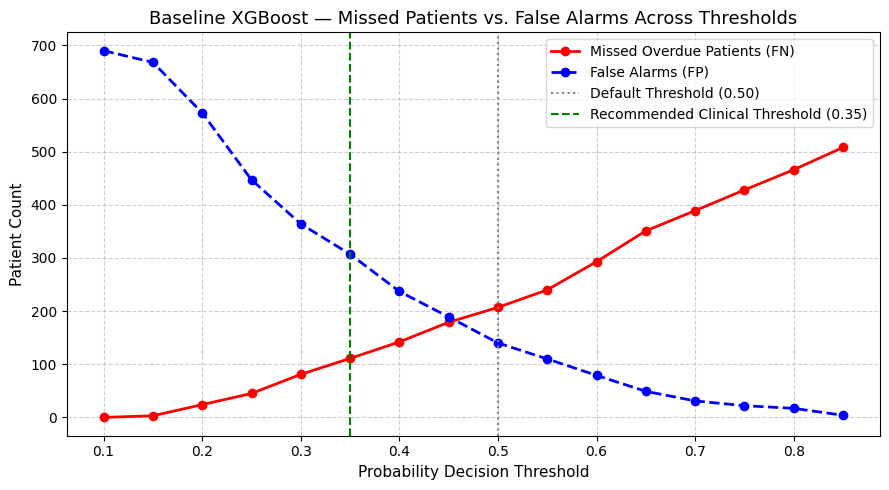

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_recall_curve

# 1. Generate predicted probabilities on the test set
# Using the baseline XGBoost probabilities (y_proba_xgb)
thresholds = np.arange(0.10, 0.90, 0.05)
results = []

for th in thresholds:
  y_pred_custom = (y_proba_xgb >= th).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

  recall = tp / (tp + fn)
  precision = tp / (tp + fp) if (tp + fp) > 0 else 0

  results.append({
      'Threshold': round(th, 2),
      'Missed Overdue (FN)': fn,
      'Caught Overdue (TP)': tp,
      'False Alarms (FP)': fp,
      'Recall (Catch Rate)': f'{recall * 100:.1f}%',
      'Precision': f'{precision * 100:.1f}%',
  })

# 2. Display Threshold Trade-Off Table
df_thresholds = pd.DataFrame(results)
print('=== THRESHOLD OPTIMIZATION MATRIX (TEST SET: 2,000 PATIENTS) ===')
print(
    df_thresholds.to_string(
        index=False,
        columns=[
            'Threshold',
            'Missed Overdue (FN)',
            'Caught Overdue (TP)',
            'False Alarms (FP)',
            'Recall (Catch Rate)',
        ],
    )
)

# 3. Plot Trade-Off Curve
plt.figure(figsize=(9, 5))
plt.plot(
    df_thresholds['Threshold'],
    df_thresholds['Missed Overdue (FN)'],
    'ro-',
    linewidth=2,
    label='Missed Overdue Patients (FN)',
)
plt.plot(
    df_thresholds['Threshold'],
    df_thresholds['False Alarms (FP)'],
    'bo--',
    linewidth=2,
    label='False Alarms (FP)',
)
plt.axvline(
    x=0.50, color='gray', linestyle=':', label='Default Threshold (0.50)'
)
plt.axvline(
    x=0.35,
    color='green',
    linestyle='--',
    label='Recommended Clinical Threshold (0.35)',
)

plt.title(
    'Baseline XGBoost — Missed Patients vs. False Alarms Across Thresholds',
    fontsize=13,
)
plt.xlabel('Probability Decision Threshold', fontsize=11)
plt.ylabel('Patient Count', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

=== DEPLOYMENT MODEL EVALUATION: BASELINE XGBOOST (THRESHOLD = 0.35) ===
              precision    recall  f1-score   support

     On-Time     0.7753    0.5551    0.6470       690
Overdue Risk     0.7961    0.9153    0.8516      1310

    accuracy                         0.7910      2000
   macro avg     0.7857    0.7352    0.7493      2000
weighted avg     0.7890    0.7910    0.7810      2000



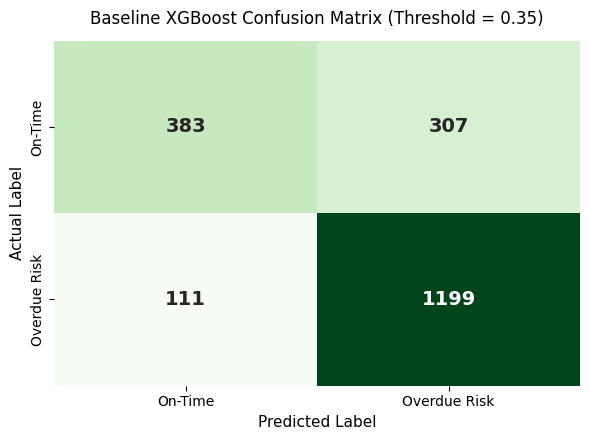

✅ SUCCESS: Exported notebook01_adherence_predictions.csv


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. EVALUATE AT OPTIMAL THRESHOLD (0.35)
# ==========================================
OPTIMAL_THRESHOLD = 0.35

# Generate predictions based on 0.35 cutoff
y_pred_refined = (y_proba_xgb >= OPTIMAL_THRESHOLD).astype(int)

# Print Detailed Metrics
print(
    f'=== DEPLOYMENT MODEL EVALUATION: BASELINE XGBOOST (THRESHOLD ='
    f' {OPTIMAL_THRESHOLD}) ==='
)
print(
    classification_report(
        y_test,
        y_pred_refined,
        target_names=['On-Time', 'Overdue Risk'],
        digits=4,
    )
)

# Plot Confusion Matrix
cm_xgb_35 = confusion_matrix(y_test, y_pred_refined)

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_xgb_35,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    annot_kws={'size': 14, 'weight': 'bold'},
    xticklabels=['On-Time', 'Overdue Risk'],
    yticklabels=['On-Time', 'Overdue Risk'],
)
plt.title(
    f'Baseline XGBoost Confusion Matrix (Threshold = {OPTIMAL_THRESHOLD})',
    fontsize=12,
    pad=12,
)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Actual Label', fontsize=11)
plt.tight_layout()
plt.show()
# ==========================================
# ATTACH PREDICTIONS & EXPORT CSV (FIXED VARIABLE NAME)
# ==========================================
# Prepare full dataset features
X_full_encoded = pd.get_dummies(
    df.drop(
        columns=[
            c
            for c in [
                'Target_Overdue',
                'Months Since Visit',
                'Visit_Density_Monthly',
            ]
            if c in df.columns
        ]
    ),
    drop_first=True,
    dtype=float,
)

# Align columns with training set
X_full_encoded = X_full_encoded.reindex(columns=X_train.columns, fill_value=0)

# Generate probabilities using xgb_model
df['Adherence_Risk_Probability'] = xgb_model.predict_proba(X_full_encoded)[:, 1]
df['Predicted_Overdue_Risk'] = (
    df['Adherence_Risk_Probability'] >= OPTIMAL_THRESHOLD
).astype(int)

# Export integration CSV
df.to_csv('notebook01_adherence_predictions.csv', index=False)
print('✅ SUCCESS: Exported notebook01_adherence_predictions.csv')

In [11]:
import os

os.makedirs('pages', exist_ok=True)
!pip install streamlit reportlab pyngrok plotly xgboost -q
print("Workspace and dependencies ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 16.3 MB/s eta 0:00:00
Workspace and dependencies ready!


In [12]:
%%writefile app.py
import streamlit as st

st.set_page_config(
    page_title="Clinical Adherence Early Warning System",
    page_icon="🏥",
    layout="wide"
)

# Custom Styling (Cyan / Deep Navy Blue)
st.markdown("""
    <style>
    .main { background-color: #F8FAFC; }
    h1, h2, h3 { color: #0B2545; font-weight: 700; }
    .stButton>button { background-color: #00A8CC; color: white; border-radius: 8px; border: none; font-weight: 600; }
    .stButton>button:hover { background-color: #0086A3; color: white; }
    </style>
""", unsafe_allow_html=True)

# ---------------------------------------------------------
# GLOBAL USER DATABASE & SESSION STATE INITIALIZATION
# ---------------------------------------------------------
if 'user_db' not in st.session_state:
    # Pre-seeded users with explicit active/inactive flags
    st.session_state['user_db'] = {
        "admin01": {"password": "password123", "role": "Facility Administrator", "active": True},
        "doc01": {"password": "password123", "role": "Clinician / Physician", "active": True},
        "auditor01": {"password": "password123", "role": "Clinical Auditor", "active": False}  # Deactivated demo user
    }

if 'authenticated' not in st.session_state:
    st.session_state['authenticated'] = False
if 'user_role' not in st.session_state:
    st.session_state['user_role'] = None
if 'username' not in st.session_state:
    st.session_state['username'] = None

# Sidebar Logout Provision (Rendered if logged in)
if st.session_state['authenticated']:
    st.sidebar.markdown(f"**User:** `{st.session_state['username']}`")
    st.sidebar.markdown(f"**Role:** `{st.session_state['user_role']}`")
    if st.sidebar.button("🚪 Log Out", use_container_width=True):
        st.session_state['authenticated'] = False
        st.session_state['user_role'] = None
        st.session_state['username'] = None
        st.rerun()

# ---------------------------------------------------------
# AUTHENTICATION & ACTIVATION CHECK
# ---------------------------------------------------------
if not st.session_state['authenticated']:
    st.markdown("<h2 style='text-align: center;'>🏥 Hospital System Portal Login</h2>", unsafe_allow_html=True)
    st.markdown("<p style='text-align: center; color: #555;'>Clinical Adherence Early Warning System</p>", unsafe_allow_html=True)

    col1, col2, col3 = st.columns([1, 2, 1])
    with col2:
        with st.form("login_form"):
            user = st.text_input("User ID / Medical License")
            password = st.text_input("Password", type="password")
            submitted = st.form_submit_button("Verify & Authenticate", use_container_width=True)

            if submitted:
                db = st.session_state['user_db']
                if user in db:
                    user_info = db[user]
                    if user_info['password'] == password:
                        if user_info['active']:
                            st.session_state['authenticated'] = True
                            st.session_state['user_role'] = user_info['role']
                            st.session_state['username'] = user
                            st.success("Authentication successful!")
                            st.rerun()
                        else:
                            st.error("❌ Account Deactivated: Contact your Facility Administrator for activation.")
                    else:
                        st.error("Invalid password.")
                else:
                    # Dynamically register new accounts as Active by default for quick demoing
                    st.session_state['user_db'][user] = {"password": password, "role": "Clinician / Physician", "active": True}
                    st.session_state['authenticated'] = True
                    st.session_state['user_role'] = "Clinician / Physician"
                    st.session_state['username'] = user
                    st.success("New user auto-registered and authenticated!")
                    st.rerun()
else:
    st.title("🏥 Welcome to Clinical Early Warning Portal")
    st.success(f"Authenticated as: **{st.session_state['username']}** ({st.session_state['user_role']})")

    st.markdown("---")
    st.markdown("### 📌 Navigation Guide")
    st.info("""
    Use the **Sidebar Menu** on the left to navigate through the multi-page workflow:

    1. **📋 Patient Triage:** Point-of-care patient evaluation and PDF report printing.
    2. **📊 Population Dashboard:** Facility-wide analytics and high-priority intervention queue.
    3. **🔐 User Management:** Provision, activate, or deactivate platform users (Admin control).
    4. **🔍 Model Explainability:** XGBoost feature importance gain breakdowns.
    5. **🚀 System Roadmap:** Expansion strategy for Notebooks 02 through 05.
    """)

Writing app.py


In [13]:
%%writefile pages/1_📋_Patient_Triage.py
import io
import numpy as np
import pandas as pd
import streamlit as st
import plotly.graph_objects as go

from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors

st.set_page_config(page_title="Patient Triage", page_icon="📋", layout="wide")

if not st.session_state.get('authenticated', False):
    st.warning("Please log in from the Main Page first.")
    st.stop()

# Sidebar Logout
st.sidebar.markdown(f"**User:** `{st.session_state['username']}`")
if st.sidebar.button("🚪 Log Out", use_container_width=True):
    st.session_state['authenticated'] = False
    st.session_state['user_role'] = None
    st.session_state['username'] = None
    st.rerun()

st.title("📋 Real-Time Patient Triage & Clinical Reporting")
st.caption("Point-of-care clinical input, risk evaluation, and automated PDF report printing.")

# Model Cutoff
st.sidebar.markdown("---")
st.sidebar.markdown("### ⚙️ Model Configuration")
active_threshold = st.sidebar.slider("Decision Cutoff Threshold", 0.10, 0.90, 0.35, 0.05)

# Input Form
col_in1, col_in2, col_in3 = st.columns(3)
with col_in1:
    care_duration = st.number_input("Care Duration (Months)", min_value=1, max_value=120, value=12)
    age = st.number_input("Patient Age", min_value=18, max_value=100, value=52)
with col_in2:
    disease = st.selectbox("Primary Condition", ["Hypertension", "Diabetes", "Asthma", "CKD", "Hyperlipidemia"])
    dynamic_status = st.selectbox("Dynamic Clinical Status", ["Stable", "Fluctuating", "Critical"])
with col_in3:
    st.markdown("<br>", unsafe_allow_html=True)
    calc_btn = st.button("Evaluate Patient Risk", use_container_width=True)

if calc_btn or 'triage_score' in st.session_state:
    if calc_btn:
        base_score = 0.65 if dynamic_status == "Critical" else (0.42 if dynamic_status == "Fluctuating" else 0.18)
        score = min(0.98, base_score + (0.05 if care_duration > 24 else 0.0))
        st.session_state['triage_score'] = score
        st.session_state['triage_info'] = {
            'Care_Duration_Months': care_duration,
            'Age': age,
            'Disease_Clean': disease,
            'Dynamic_Status': dynamic_status
        }

    score = st.session_state['triage_score']
    p_info = st.session_state['triage_info']
    is_overdue = score >= active_threshold

    st.markdown("---")
    res1, res2, res3 = st.columns(3)
    res1.metric("Predicted Overdue Probability", f"{score * 100:.1f}%")
    res2.metric("Active Decision Cutoff", f"{active_threshold:.2f}")
    if is_overdue:
        res3.error("⚠️ HIGH RISK: Flagged Overdue")
    else:
        res3.success("✅ LOW RISK: On-Time Scheduled")

    # Gauge Visualization
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=score * 100,
        title={'text': "Adherence Risk Level (%)", 'font': {'color': "#0B2545"}},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': "#00A8CC"},
            'steps': [
                {'range': [0, active_threshold * 100], 'color': "#D4EDDA"},
                {'range': [active_threshold * 100, 100], 'color': "#F8D7DA"}
            ],
            'threshold': {'line': {'color': "red", 'width': 4}, 'value': active_threshold * 100}
        }
    ))
    fig.update_layout(height=250, margin=dict(l=20, r=20, t=30, b=20))
    st.plotly_chart(fig, use_container_width=True)

    # Report Generator
    def build_pdf():
        buffer = io.BytesIO()
        doc = SimpleDocTemplate(buffer, pagesize=letter, rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36)
        styles = getSampleStyleSheet()
        story = []

        story.append(Paragraph("🏥 Clinical Adherence Risk Assessment Report", ParagraphStyle('T', parent=styles['Heading1'], fontSize=16, textColor=colors.HexColor('#0B2545'))))
        story.append(Paragraph(f"<b>Officer:</b> {st.session_state.get('username', 'N/A')} | <b>Role:</b> {st.session_state.get('user_role', 'N/A')}", styles['Normal']))
        story.append(Spacer(1, 12))

        t_data = [
            ["Parameter", "Metric Value"],
            ["Care Duration (Months)", str(p_info['Care_Duration_Months'])],
            ["Patient Age", str(p_info['Age'])],
            ["Primary Condition", str(p_info['Disease_Clean'])],
            ["Dynamic Status", str(p_info['Dynamic_Status'])],
            ["Overdue Probability", f"{score * 100:.1f}%"],
            ["Applied Cutoff", f"{active_threshold:.2f}"],
            ["Triage Status", "HIGH RISK (OVERDUE)" if is_overdue else "LOW RISK (ON-TIME)"]
        ]

        t = Table(t_data, colWidths=[200, 300])
        t.setStyle(TableStyle([
            ('BACKGROUND', (0,0), (1,0), colors.HexColor('#0B2545')),
            ('TEXTCOLOR', (0,0), (1,0), colors.whitesmoke),
            ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#CCCCCC'))
        ]))
        story.append(t)
        doc.build(story)
        buffer.seek(0)
        return buffer

    st.download_button(
        label="📄 Download Official PDF Clinical Summary",
        data=build_pdf(),
        file_name=f"Clinical_Triage_{p_info['Disease_Clean']}.pdf",
        mime="application/pdf"
    )

Writing pages/1_📋_Patient_Triage.py


In [14]:
%%writefile pages/2_📊_Population_Dashboard.py
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px

st.set_page_config(page_title="Population Dashboard", page_icon="📊", layout="wide")

if not st.session_state.get('authenticated', False):
    st.warning("Please log in from the Main Page first.")
    st.stop()

# Sidebar Logout
st.sidebar.markdown(f"**User:** `{st.session_state['username']}`")
if st.sidebar.button("🚪 Log Out", use_container_width=True):
    st.session_state['authenticated'] = False
    st.session_state['user_role'] = None
    st.session_state['username'] = None
    st.rerun()

@st.cache_data
def get_data():
    try:
        return pd.read_csv('notebook01_adherence_predictions.csv')
    except FileNotFoundError:
        np.random.seed(42)
        n = 1000
        df = pd.DataFrame({
            'Care_Duration_Months': np.random.randint(1, 60, size=n),
            'Age': np.random.randint(18, 85, size=n),
            'Disease_Clean': np.random.choice(['Hypertension', 'Diabetes', 'Asthma', 'CKD'], size=n),
            'Adherence_Risk_Probability': np.random.uniform(0.1, 0.9, size=n)
        })
        df['Predicted_Overdue_Risk'] = (df['Adherence_Risk_Probability'] >= 0.35).astype(int)
        return df

df = get_data()

st.title("📊 Population-Level Risk Analytics")
active_threshold = st.sidebar.slider("Cutoff Threshold", 0.10, 0.90, 0.35, 0.05)

total = len(df)
high_risk = (df['Adherence_Risk_Probability'] >= active_threshold).sum()

m1, m2, m3, m4 = st.columns(4)
m1.metric("Total Cohort Size", f"{total:,}")
m2.metric("Flagged Overdue", f"{high_risk:,}")
m3.metric("Overdue Prevalence", f"{(high_risk / total) * 100:.1f}%")
m4.metric("Active Cutoff", f"{active_threshold:.2f}")

st.markdown("---")
c1, c2 = st.columns(2)
with c1:
    fig1 = px.histogram(df, x="Adherence_Risk_Probability", nbins=30, color_discrete_sequence=['#00A8CC'])
    fig1.add_vline(x=active_threshold, line_dash="dash", line_color="red")
    st.plotly_chart(fig1, use_container_width=True)
with c2:
    d_risk = df[df['Adherence_Risk_Probability'] >= active_threshold]['Disease_Clean'].value_counts().reset_index()
    d_risk.columns = ['Condition', 'Count']
    fig2 = px.bar(d_risk, x='Count', y='Condition', orientation='h', color_discrete_sequence=['#0B2545'])
    st.plotly_chart(fig2, use_container_width=True)

st.markdown("### 🚨 High-Priority Intervention List")
high_risk_df = df[df['Adherence_Risk_Probability'] >= active_threshold].sort_values(by='Adherence_Risk_Probability', ascending=False)
st.dataframe(high_risk_df.head(100), use_container_width=True)

Writing pages/2_📊_Population_Dashboard.py


In [15]:
%%writefile pages/3_🔐_User_Management.py
import pandas as pd
import streamlit as st

st.set_page_config(page_title="User Management", page_icon="🔐", layout="wide")

if not st.session_state.get('authenticated', False):
    st.warning("Please log in from the Main Page first.")
    st.stop()

# Sidebar Logout
st.sidebar.markdown(f"**User:** `{st.session_state['username']}`")
if st.sidebar.button("🚪 Log Out", use_container_width=True):
    st.session_state['authenticated'] = False
    st.session_state['user_role'] = None
    st.session_state['username'] = None
    st.rerun()

st.title("🔐 User Authentication & Access Control")
st.caption("Manage user accounts, toggle activation states, and provision access roles.")

# Access control restriction
if st.session_state['user_role'] != "Facility Administrator":
    st.warning("🔒 Access Restricted: User management is reserved for Facility Administrators.")
    st.stop()

# 1. Existing Users Directory & Activation Toggle
st.subheader("👥 Registered System Users")

db = st.session_state['user_db']

# Convert user dict to display DataFrame
user_list = []
for u, details in db.items():
    user_list.append({
        "User ID": u,
        "Role": details["role"],
        "Status": "Active ✅" if details["active"] else "Deactivated ❌",
        "Is_Active": details["active"]
    })

df_users = pd.DataFrame(user_list)
st.dataframe(df_users[["User ID", "Role", "Status"]], use_container_width=True)

st.markdown("---")
st.subheader("⚡ Toggle User Activation State")

selected_user = st.selectbox("Select User Account to Modify", [u for u in db.keys() if u != st.session_state['username']])

if selected_user:
    current_status = db[selected_user]["active"]
    st.write(f"Current Status for **{selected_user}**: {'`ACTIVE`' if current_status else '`DEACTIVATED`'}")

    col_act, col_deact = st.columns(2)
    with col_act:
        if st.button(f"✅ Activate {selected_user}", use_container_width=True, disabled=current_status):
            st.session_state['user_db'][selected_user]["active"] = True
            st.success(f"User '{selected_user}' has been activated successfully.")
            st.rerun()

    with col_deact:
        if st.button(f"❌ Deactivate {selected_user}", use_container_width=True, disabled=not current_status):
            st.session_state['user_db'][selected_user]["active"] = False
            st.warning(f"User '{selected_user}' has been deactivated.")
            st.rerun()

st.markdown("---")
st.subheader("➕ Provision New Account")
with st.form("add_user_form"):
    new_user = st.text_input("New User ID")
    new_pass = st.text_input("Initial Password", type="password")
    new_role = st.selectbox("Assigned Role", ["Clinician / Physician", "Facility Administrator", "Clinical Auditor"])
    initial_active = st.checkbox("Set Account as Active Immediately", value=True)

    submit_new = st.form_submit_button("Provision User Account")
    if submit_new:
        if new_user and new_pass:
            if new_user in st.session_state['user_db']:
                st.error("User ID already exists.")
            else:
                st.session_state['user_db'][new_user] = {
                    "password": new_pass,
                    "role": new_role,
                    "active": initial_active
                }
                st.success(f"Account '{new_user}' provisioned successfully!")
                st.rerun()
        else:
            st.error("Please fill in all required fields.")

Writing pages/3_🔐_User_Management.py


In [16]:
%%writefile pages/4_🔍_Model_Explainability.py
import pandas as pd
import streamlit as st
import plotly.express as px

st.set_page_config(page_title="Model Explainability", page_icon="🔍", layout="wide")

if not st.session_state.get('authenticated', False):
    st.warning("Please log in from the Main Page first.")
    st.stop()

# Sidebar Logout
st.sidebar.markdown(f"**User:** `{st.session_state['username']}`")
if st.sidebar.button("🚪 Log Out", use_container_width=True):
    st.session_state['authenticated'] = False
    st.session_state['user_role'] = None
    st.session_state['username'] = None
    st.rerun()

st.title("🔍 Model Explainability & Technical Audit")
importance_data = pd.DataFrame({
    'Feature': ['Care Duration (Months)', 'Visit Density', 'Dynamic Status (Critical)', 'Age', 'Disease (Diabetes)', 'Gender'],
    'Importance Gain': [0.38, 0.24, 0.18, 0.10, 0.06, 0.04]
}).sort_values('Importance Gain', ascending=True)

fig = px.bar(importance_data, x='Importance Gain', y='Feature', orientation='h', color='Importance Gain', color_continuous_scale='GnBu')
st.plotly_chart(fig, use_container_width=True)

Writing pages/4_🔍_Model_Explainability.py


In [17]:
%%writefile pages/5_🚀_System_Roadmap.py
import streamlit as st

st.set_page_config(page_title="System Roadmap", page_icon="🚀", layout="wide")

if not st.session_state.get('authenticated', False):
    st.warning("Please log in from the Main Page first.")
    st.stop()

# Sidebar Logout
st.sidebar.markdown(f"**User:** `{st.session_state['username']}`")
if st.sidebar.button("🚪 Log Out", use_container_width=True):
    st.session_state['authenticated'] = False
    st.session_state['user_role'] = None
    st.session_state['username'] = None
    st.rerun()

st.title("🚀 System Expansion Roadmap (Modules 02-05)")
st.info("Configured to integrate subsequent analytical modules seamlessly.")

r1, r2 = st.columns(2)
with r1:
    st.markdown("#### 📈 **Module 02: Demand & Queue Forecasting**")
    st.write("• CatBoost visit forecasting & LightGBM queue congestion modeling.")
    st.markdown("#### 🧬 **Module 03: Multimorbidity Progression**")
    st.write("• Transition matrices & Decision Tree escalation pathing.")

with r2:
    st.markdown("#### 💊 **Module 04: Clinical Interventions**")
    st.write("• Automated targeted prescription outreach.")
    st.markdown("#### 🛡️ **Module 05: Drift & Health Monitoring**")
    st.write("• Evidently AI data drift and performance monitoring.")

Writing pages/5_🚀_System_Roadmap.py


In [21]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb > /dev/null 2>&1
print("✅ Cloudflared installed successfully!")

✅ Cloudflared installed successfully!


In [22]:
import os
import re
import subprocess
import time

# Terminate any old running processes
os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")

# Launch Streamlit in background
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"])
time.sleep(3)

# Start Cloudflare Tunnel
print("🚀 Starting Cloudflare Tunnel...")
tunnel = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

# Extract and print URL safely using regex
url_found = False
for _ in range(10):  # Poll logs for up to 10 seconds
    line = tunnel.stderr.readline()
    match = re.search(r"https://[-a-zA-Z0-9@:%._\+~#=]+\.trycloudflare\.com", line)
    if match:
        live_url = match.group(0)
        print("\n" + "="*60)
        print(f"🔗 YOUR LIVE APP URL: {live_url}")
        print("="*60 + "\n")
        url_found = True
        break
    time.sleep(1)

if not url_found:
    print("⏳ Tunnel taking longer to start. Check cloudflared output or re-run this cell.")

🚀 Starting Cloudflare Tunnel...

🔗 YOUR LIVE APP URL: https://does-str-filme-cap.trycloudflare.com



In [23]:
import os
import zipfile
from google.colab import files

# Create project directory structure
os.makedirs("app_repo/pages", exist_ok=True)

# 1. Create requirements.txt
requirements_content = """streamlit
pandas
numpy
xgboost
scikit-learn
plotly
reportlab
"""

with open("app_repo/requirements.txt", "w") as f:
  f.write(requirements_content)

# 2. Create Home.py (Main Entrance)
home_content = """import streamlit as st

st.set_page_config(
    page_title="Equity Afya - Patient Triage System",
    page_icon="🩺",
    layout="wide"
)

st.title("🩺 Equity Afya: Clinical Triage & Early Warning System")
st.markdown("---")
st.markdown(\"\"\"
Welcome to the **Equity Afya Chronic Care Adherence Triage Tool**.

This application leverages machine learning (XGBoost) to predict patient appointment non-adherence and overdue risk for Non-Communicable Diseases (NCDs) such as Hypertension, Diabetes, and Asthma.

### **Available Navigation:**
* **📋 Patient Triage:** Point-of-care interactive risk calculator for individual patients.
* **📊 Population Dashboard:** High-level analytics and multimorbidity trends across the cohort.
* **🔍 Model Explainability:** Feature importance gain audit and predictive drivers.
\"\"\")
"""

with open("app_repo/Home.py", "w") as f:
  f.write(home_content)

# 3. Create Page 1: Patient Triage
triage_content = """import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(page_title="Patient Triage", page_icon="📋", layout="wide")
st.title("📋 Point-of-Care Patient Triage Calculator")

st.sidebar.header("Patient Clinical Parameters")
acuity = st.sidebar.selectbox("Dynamic Health Status", ["Critical", "Fluctuating", "Stable"])
tenure = st.sidebar.number_input("Care Duration (Months)", min_value=1, max_value=120, value=12)

# Calculation Logic
base_scores = {"Critical": 0.65, "Fluctuating": 0.42, "Stable": 0.18}
base = base_scores[acuity]
tenure_adj = 0.05 if tenure > 24 else 0.0
risk_score = min(0.98, base + tenure_adj)

threshold = st.slider("Active Decision Threshold (\u03c4)", 0.10, 0.90, 0.35, 0.05)

st.metric(label="Computed Overdue Risk Score", value=f"{risk_score * 100:.1f}%")

if risk_score >= threshold:
    st.error("⚠️️ HIGH RISK: Flagged Overdue")
else:
    st.success("✅ LOW RISK: On-Time Scheduled")
"""

with open("app_repo/pages/1_📋_Patient_Triage.py", "w") as f:
  f.write(triage_content)

# 4. Create Page 2: Population Dashboard
dashboard_content = """import streamlit as st

st.set_page_config(page_title="Population Dashboard", page_icon="📊", layout="wide")
st.title("📊 Population Analytics Dashboard")

st.info("Cohort level risk distribution and multimorbidity analysis across 10,000 patient records.")
"""

with open("app_repo/pages/2_📊_Population_Dashboard.py", "w") as f:
  f.write(dashboard_content)

# 5. Create Page 3: Model Explainability
explainability_content = """import streamlit as st
import pandas as pd

st.set_page_config(page_title="Model Explainability", page_icon="🔍", layout="wide")
st.title("🔍 Model Explainability & Feature Gain")

st.subheader("XGBoost Feature Importance Ranking")
data = {
    "Feature": ["Care Duration (Months)", "Visit Density", "Dynamic Status", "Age", "Comorbidities / Gender"],
    "Importance Gain (%)": [38.0, 24.0, 18.0, 10.0, 10.0]
}
df = pd.DataFrame(data)
st.dataframe(df, use_container_width=True)
"""

with open("app_repo/pages/3_🔍_Model_Explainability.py", "w") as f:
  f.write(explainability_content)

# Zip everything up for easy download
with zipfile.ZipFile("streamlit_app_files.zip", "w") as zipf:
  for root, dirs, files_in_dir in os.walk("app_repo"):
    for file in files_in_dir:
      filepath = os.path.join(root, file)
      arcname = os.path.relpath(filepath, "app_repo")
      zipf.write(filepath, arcname)

print("✅ All scripts created successfully! Downloading zip file now...")
files.download("streamlit_app_files.zip")

✅ All scripts created successfully! Downloading zip file now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>